# LOB Analysis
Exploratory analysis of limit order book and trade data.
Switch `DATA_DIR` and `PAIR` in the config cell to analyse any exchange/pair.

In [1]:
# ── Config ──────────────────────────────────────────────────────────────────
from pathlib import Path

DATA_DIR = Path("../data/nobitex_data")  # swap for another exchange dir
PAIR = "BTCIRT"  # filename prefix inside DATA_DIR
N_LEVELS = 10  # how many LOB levels to use

OB_FILE = DATA_DIR / f"{PAIR}_orderbook.csv"
TRADE_FILE = DATA_DIR / f"{PAIR}_trades.csv"
print(f"orderbook : {OB_FILE}")
print(f"trades    : {TRADE_FILE}")

orderbook : ../data/nobitex_data/BTCIRT_orderbook.csv
trades    : ../data/nobitex_data/BTCIRT_trades.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 4)})

## 1  Load data

In [3]:
ob = pd.read_csv(OB_FILE, parse_dates=["time"])
ob = ob.sort_values("time").reset_index(drop=True)

trades = pd.read_csv(TRADE_FILE, parse_dates=["snapshot_time", "trade_time"])
trades = trades.sort_values("trade_time").reset_index(drop=True)

print("orderbook  rows:", len(ob), " | range:", ob["time"].min(), "→", ob["time"].max())
print(
    "trades     rows:",
    len(trades),
    " | range:",
    trades["trade_time"].min(),
    "→",
    trades["trade_time"].max(),
)

orderbook  rows: 73878  | range: 2026-06-08 13:06:14 → 2026-06-17 06:15:54
trades     rows: 46524  | range: 2026-06-08 13:01:07.108000 → 2026-06-17 06:14:58.671000


In [4]:
# Separate bid / ask columns for the first N_LEVELS levels
bid_price_cols = [f"bid_price_{i}" for i in range(1, N_LEVELS + 1)]
bid_volume_cols = [f"bid_volume_{i}" for i in range(1, N_LEVELS + 1)]
ask_price_cols = [f"ask_price_{i}" for i in range(1, N_LEVELS + 1)]
ask_volume_cols = [f"ask_volume_{i}" for i in range(1, N_LEVELS + 1)]

ob.head(2)

,time,bid_price_1,bid_volume_1,ask_price_1,ask_volume_1,bid_price_2,bid_volume_2,ask_price_2,ask_volume_2,bid_price_3,...,ask_price_18,ask_volume_18,bid_price_19,bid_volume_19,ask_price_19,ask_volume_19,bid_price_20,bid_volume_20,ask_price_20,ask_volume_20
0,2026-06-08 13:06:14,112825000000,0.013633,112700000000,0.016998,112829989940,0.000727,112686856600,0.000044,112829989950,...,111080990000,0.0001,113000000000,0.011774,111016872360,0.000012,113000008000,0.0002,111000000010,0.009882
1,2026-06-08 13:06:24,112825000000,0.013552,112700000000,0.016077,112829989940,0.000727,112686856600,0.000044,112829989950,...,111080990000,0.0001,113000000000,0.011774,111016872360,0.000012,113000008000,0.0002,111000000010,0.009882


In [5]:
trades.head(2)

,snapshot_time,trade_time,price,volume,direction
0,2026-06-08 13:06:14,2026-06-08 13:01:07.108,112825000000,0.000425,buy
1,2026-06-08 13:06:14,2026-06-08 13:01:24.994,112700000000,0.001683,sell


## 2  Derived series

In [6]:
ob["mid_price"] = (ob["bid_price_1"] + ob["ask_price_1"]) / 2
ob["spread"] = ob["ask_price_1"] - ob["bid_price_1"]
ob["spread_bps"] = ob["spread"] / ob["mid_price"] * 1e4

# Total depth at each level
ob["total_bid_vol"] = ob[bid_volume_cols].sum(axis=1)
ob["total_ask_vol"] = ob[ask_volume_cols].sum(axis=1)

# Order-book imbalance (OBI) using best-level volumes
ob["obi"] = (ob["bid_volume_1"] - ob["ask_volume_1"]) / (
    ob["bid_volume_1"] + ob["ask_volume_1"]
).replace(0, np.nan)

ob[
    [
        "time",
        "mid_price",
        "spread",
        "spread_bps",
        "total_bid_vol",
        "total_ask_vol",
        "obi",
    ]
].describe()

,time,mid_price,spread,spread_bps,total_bid_vol,total_ask_vol,obi
count,73878,7.387800e+04,7.387800e+04,7.387800e+04,73878.000000,73878.000000,73878.000000
mean,2026-06-12 21:16:43.908849408,1.092809e+11,-1.874220e+08,-1.717814e+01,0.048461,0.047065,0.042234
min,2026-06-08 13:06:14,1.008748e+11,-1.258285e+09,-1.152918e+02,0.001051,0.000192,-0.999921
25%,2026-06-10 16:56:36.500000,1.084012e+11,-2.870061e+08,-2.632885e+01,0.025155,0.028417,-0.646642
50%,2026-06-12 20:26:59,1.097690e+11,-1.814297e+08,-1.669265e+01,0.039735,0.040257,0.032605
75%,2026-06-15 01:58:26.500000,1.114194e+11,-6.012527e+07,-5.500830e+00,0.061082,0.058553,0.752647
max,2026-06-17 06:15:54,1.140000e+11,-1.000000e+01,-8.771930e-07,0.379457,0.257525,0.999921
std,NaN,3.000357e+09,1.424683e+08,1.306982e+01,0.034607,0.029324,0.699567


## 3  Mid-price & spread over time

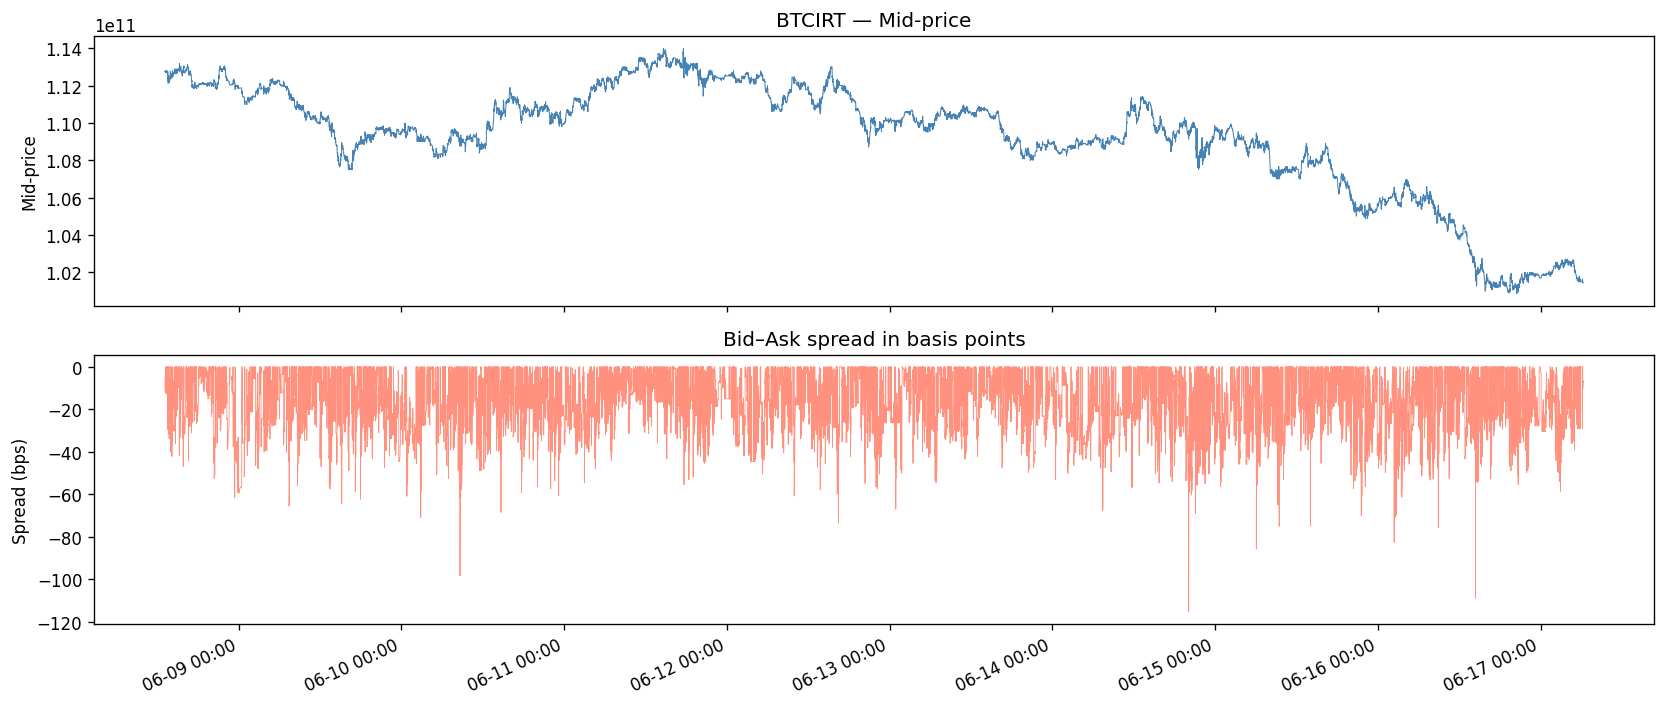

In [7]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 6))

axes[0].plot(ob["time"], ob["mid_price"], lw=0.6, color="steelblue")
axes[0].set_ylabel("Mid-price")
axes[0].set_title(f"{PAIR} — Mid-price")

axes[1].plot(ob["time"], ob["spread_bps"], lw=0.5, color="tomato", alpha=0.7)
axes[1].set_ylabel("Spread (bps)")
axes[1].set_title("Bid–Ask spread in basis points")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 4  Average LOB depth profile

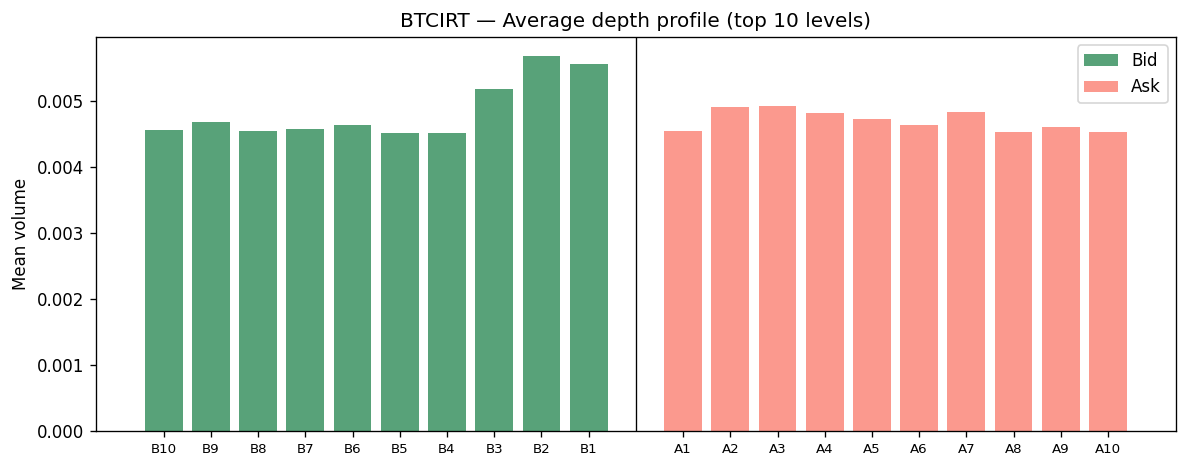

In [8]:
# Mean volume at each level (relative to best bid/ask price)
mean_bid_vol = ob[bid_volume_cols].mean()
mean_ask_vol = ob[ask_volume_cols].mean()

levels = range(1, N_LEVELS + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    [-lv for lv in levels], mean_bid_vol.values, color="seagreen", alpha=0.8, label="Bid"
)
ax.bar(
    [+lv for lv in levels], mean_ask_vol.values, color="salmon", alpha=0.8, label="Ask"
)
ax.axvline(0, color="k", lw=0.8)
ax.set_xticks(list(-lv for lv in levels) + list(lv for lv in levels))
ax.set_xticklabels([f"B{lv}" for lv in levels] + [f"A{lv}" for lv in levels], fontsize=8)
ax.set_ylabel("Mean volume")
ax.set_title(f"{PAIR} — Average depth profile (top {N_LEVELS} levels)")
ax.legend()
plt.tight_layout()
plt.show()

## 5  Cumulative depth over time

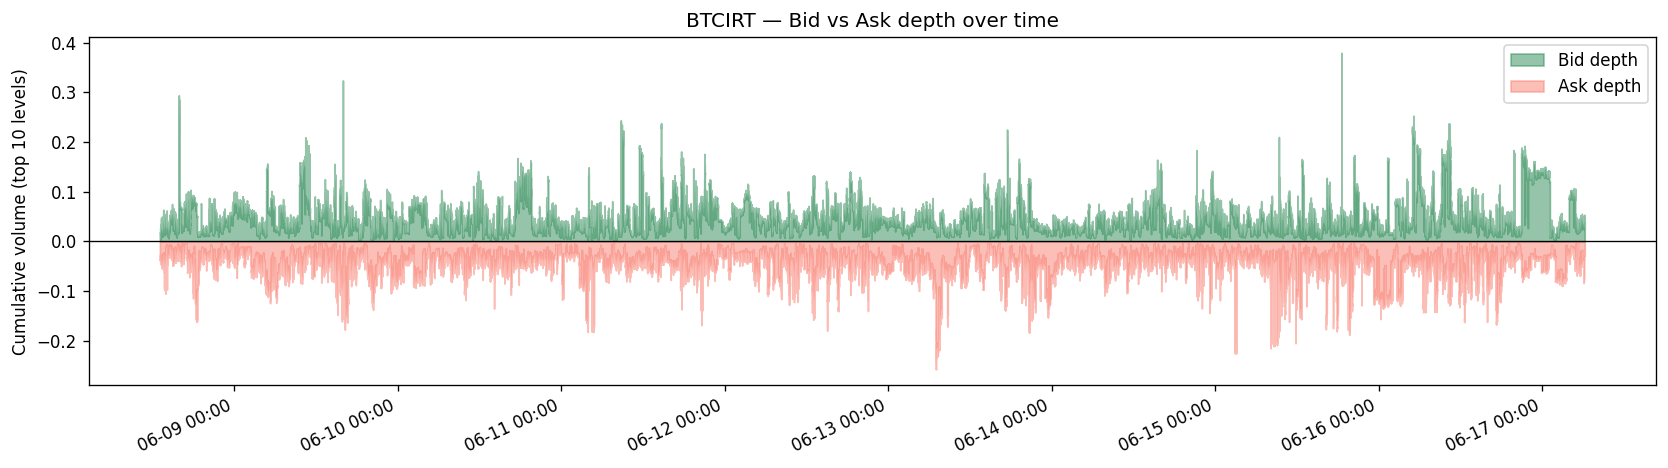

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(
    ob["time"], ob["total_bid_vol"], alpha=0.5, color="seagreen", label="Bid depth"
)
ax.fill_between(
    ob["time"], -ob["total_ask_vol"], alpha=0.5, color="salmon", label="Ask depth"
)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel(f"Cumulative volume (top {N_LEVELS} levels)")
ax.set_title(f"{PAIR} — Bid vs Ask depth over time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## 6  Order-book imbalance (OBI)

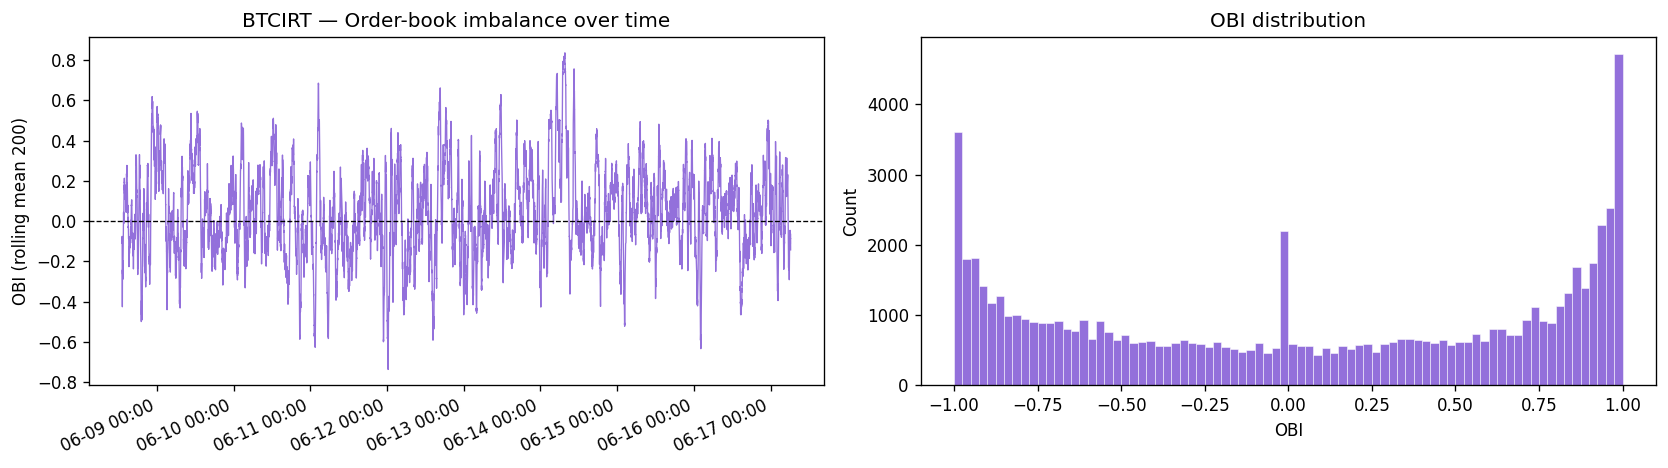

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series
axes[0].plot(
    ob["time"],
    ob["obi"].rolling(200, min_periods=1).mean(),
    lw=0.8,
    color="mediumpurple",
)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_ylabel("OBI (rolling mean 200)")
axes[0].set_title(f"{PAIR} — Order-book imbalance over time")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha="right")

# Distribution
axes[1].hist(
    ob["obi"].dropna(), bins=80, color="mediumpurple", edgecolor="white", lw=0.3
)
axes[1].set_xlabel("OBI")
axes[1].set_ylabel("Count")
axes[1].set_title("OBI distribution")

plt.tight_layout()
plt.show()

## 7  LOB heatmap (price × time)

In [11]:
# Downsample to at most 2000 snapshots for plotting performance
HMAP_ROWS = 2000
step = max(1, len(ob) // HMAP_ROWS)
ob_s = ob.iloc[::step].copy()

# Build a 2-D grid: rows = time snapshots, cols = price bins
all_bid_prices = ob_s[bid_price_cols].values
all_ask_prices = ob_s[ask_price_cols].values
all_bid_vols = ob_s[bid_volume_cols].values
all_ask_vols = ob_s[ask_volume_cols].values

p_min = np.nanpercentile(all_bid_prices, 1)
p_max = np.nanpercentile(all_ask_prices, 99)
N_BINS = 200
price_bins = np.linspace(p_min, p_max, N_BINS + 1)

hmap = np.zeros((len(ob_s), N_BINS))

for row_idx in range(len(ob_s)):
    for lvl in range(N_LEVELS):
        for prices, vols in [
            (all_bid_prices[:, lvl], all_bid_vols[:, lvl]),
            (all_ask_prices[:, lvl], all_ask_vols[:, lvl]),
        ]:
            p = prices[row_idx]
            v = vols[row_idx]
            if np.isnan(p) or p < p_min or p > p_max:
                continue
            bin_idx = np.searchsorted(price_bins, p, side="right") - 1
            bin_idx = np.clip(bin_idx, 0, N_BINS - 1)
            hmap[row_idx, bin_idx] += v

print(f"Heatmap shape: {hmap.shape}")

Heatmap shape: (2053, 200)


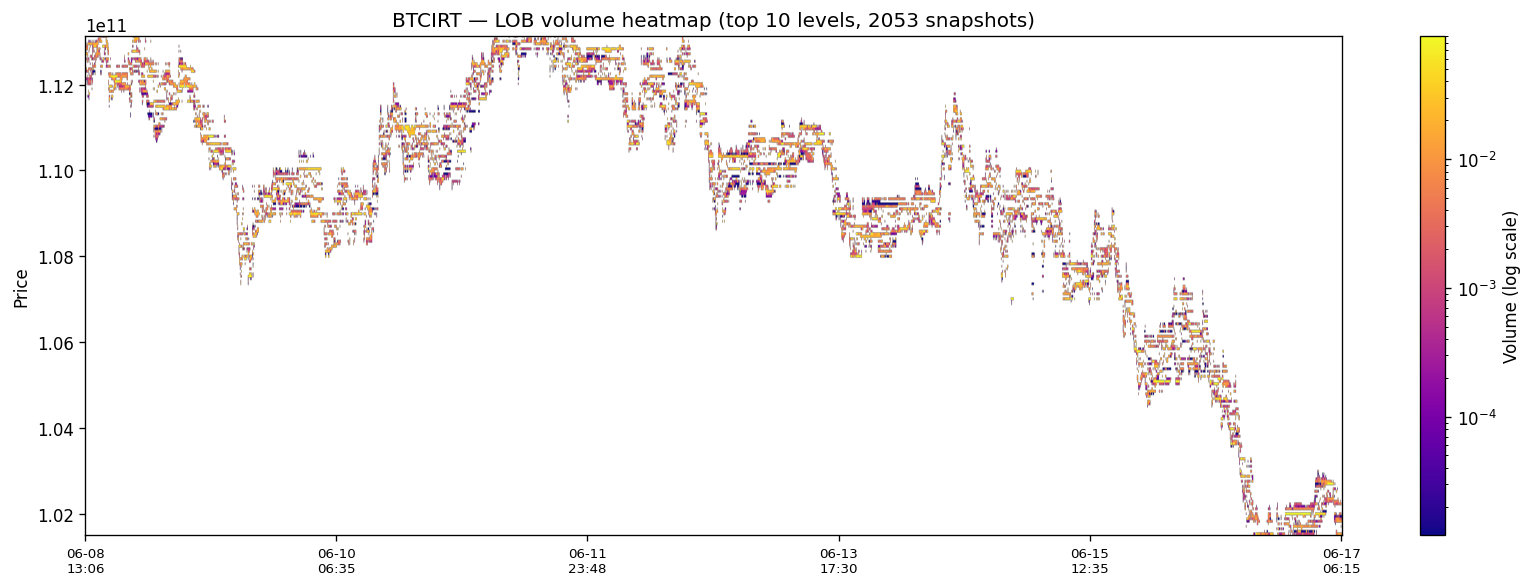

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

hmap_nonzero = np.where(hmap > 0, hmap, np.nan)
im = ax.imshow(
    hmap_nonzero.T,
    aspect="auto",
    origin="lower",
    norm=LogNorm(
        vmin=np.nanpercentile(hmap_nonzero, 5), vmax=np.nanpercentile(hmap_nonzero, 99)
    ),
    cmap="plasma",
    extent=[0, len(ob_s), p_min, p_max],
)
plt.colorbar(im, ax=ax, label="Volume (log scale)")

# x-axis: convert row indices back to timestamps
n_ticks = 6
tick_idx = np.linspace(0, len(ob_s) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels(
    [ob_s["time"].iloc[i].strftime("%m-%d\n%H:%M") for i in tick_idx], fontsize=8
)
ax.set_ylabel("Price")
ax.set_title(
    f"{PAIR} — LOB volume heatmap (top {N_LEVELS} levels, {len(ob_s)} snapshots)"
)
plt.tight_layout()
plt.show()

## 8  Trade analysis

In [13]:
trades["direction"].value_counts()

direction
sell    28746
buy     17778
Name: count, dtype: int64

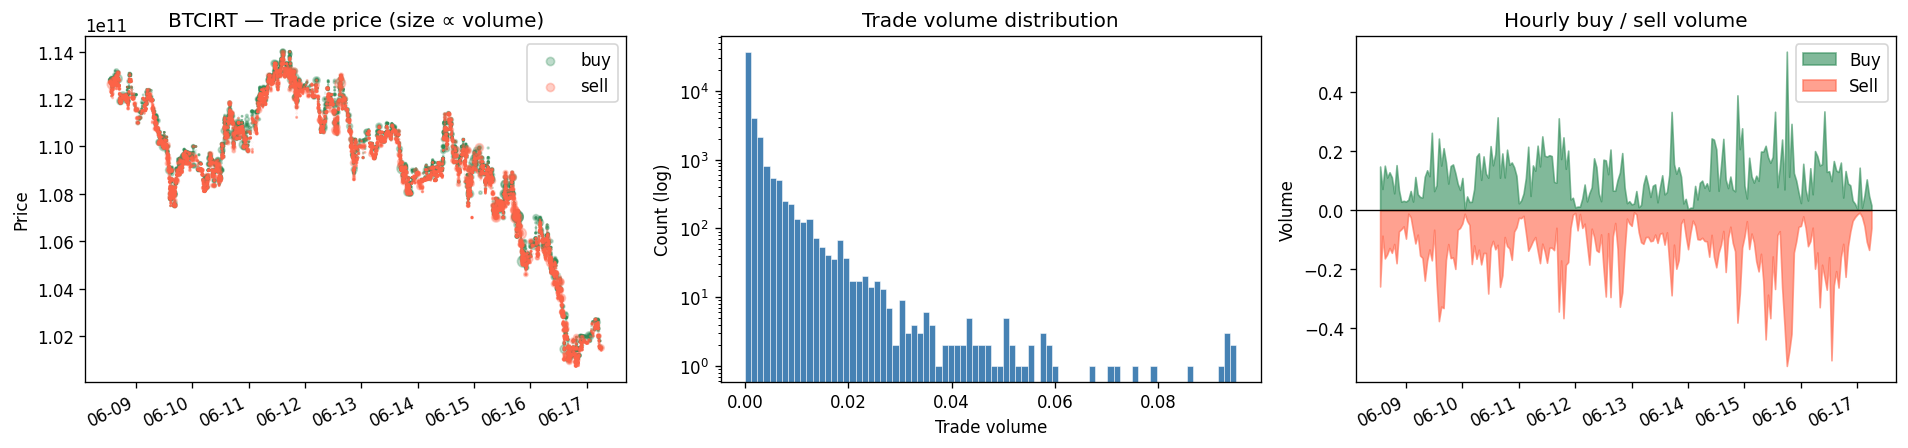

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trade price vs time
for direction, color in [("buy", "seagreen"), ("sell", "tomato")]:
    mask = trades["direction"] == direction
    axes[0].scatter(
        trades.loc[mask, "trade_time"],
        trades.loc[mask, "price"],
        s=trades.loc[mask, "volume"] * 500,
        alpha=0.3,
        color=color,
        label=direction,
    )
axes[0].set_title(f"{PAIR} — Trade price (size ∝ volume)")
axes[0].set_ylabel("Price")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha="right")
axes[0].legend()

# Volume distribution
axes[1].hist(
    trades["volume"], bins=80, color="steelblue", edgecolor="white", lw=0.3, log=True
)
axes[1].set_xlabel("Trade volume")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Trade volume distribution")

# Buy / sell volume per hour
trades["hour"] = trades["trade_time"].dt.floor("h")
hourly = trades.groupby(["hour", "direction"])["volume"].sum().unstack(fill_value=0)
if "buy" in hourly.columns:
    axes[2].fill_between(
        hourly.index, hourly["buy"], alpha=0.6, color="seagreen", label="Buy"
    )
if "sell" in hourly.columns:
    axes[2].fill_between(
        hourly.index, -hourly["sell"], alpha=0.6, color="tomato", label="Sell"
    )
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_title("Hourly buy / sell volume")
axes[2].set_ylabel("Volume")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=25, ha="right")
axes[2].legend()

plt.tight_layout()
plt.show()

## 9  Trade flow vs mid-price

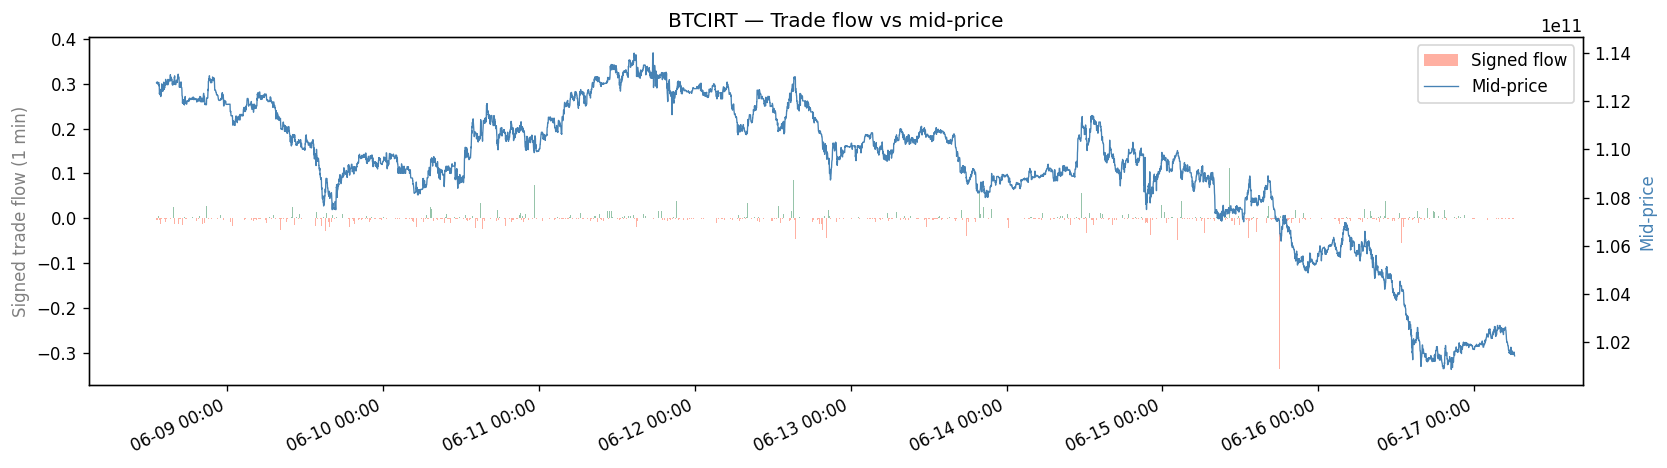

In [15]:
# Signed trade flow: buy = +volume, sell = -volume
trades["signed_volume"] = trades["volume"] * trades["direction"].map(
    {"buy": 1, "sell": -1}
)

# Resample to same frequency as OB snapshots (1-min buckets)
flow_1m = (
    trades.set_index("trade_time")["signed_volume"].resample("1min").sum().fillna(0)
)
mid_1m = ob.set_index("time")["mid_price"].resample("1min").last().ffill()

combined = pd.concat([flow_1m, mid_1m], axis=1, join="inner")
combined.columns = ["signed_flow", "mid_price"]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(
    combined.index,
    combined["signed_flow"],
    color=np.where(combined["signed_flow"] >= 0, "seagreen", "tomato"),
    alpha=0.5,
    width=0.0006,
    label="Signed flow",
)
ax2.plot(
    combined.index, combined["mid_price"], color="steelblue", lw=0.8, label="Mid-price"
)

ax1.set_ylabel("Signed trade flow (1 min)", color="grey")
ax2.set_ylabel("Mid-price", color="steelblue")
ax1.set_title(f"{PAIR} — Trade flow vs mid-price")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=25, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.show()